# Preprocessing dan Klasifikasi Data Maintenance Kendaraan

Notebook ini menggunakan `data_historis_gabungan.csv` untuk melakukan preprocessing data, klasifikasi menggunakan Naive Bayes dan Decision Tree, lalu membandingkan performa model berdasarkan confusion matrix, akurasi, precision, recall, dan F1-score. Proses machine learning menggunakan library `scikit-learn`.

## 1. Import Library dan Konfigurasi Awal

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
DATA_PATH = Path("data_historis_gabungan.csv")
MODEL_OUTPUT_PATH = Path("api/model_kendaraan.pkl")
N_SPLITS = 5

## 2. Load Dataset

Data yang digunakan adalah hasil proses seleksi dan penggabungan dari tahap sebelumnya.

In [2]:
data = pd.read_csv(DATA_PATH)

print(f"Jumlah baris: {data.shape[0]}")
print(f"Jumlah kolom: {data.shape[1]}")
display(data.head())
display(data.info())

Jumlah baris: 13000
Jumlah kolom: 26


,id,umur_kendaraan,jarak_tempuh_tahun,frekuensi_servis_tahun,km_oli,km_rem,km_busi,km_ban,kelas,created_at,...,kondisi_rem,kondisi_ban,kondisi_aki,Need_Maintenance,jenis_servis_oli,jenis_servis_rem,jenis_servis_busi,jenis_servis_ban,jenis_servis_tertinggi,komponen_perlu_servis
0,853,1,25040,5,3976,14112,9616,23928,Perlu Servis,2026-07-02 02:26:06,...,Baru,Baik,Baik,1,Servis 10.000 KM,Servis 20.000 KM,Servis 10.000 KM,Servis 40.000 KM,Servis 40.000 KM,"oli, busi"
1,1008,5,25305,5,3765,30295,11505,23165,Layak,2026-07-02 02:26:06,...,Aus,Baru,Baik,1,Servis 10.000 KM,Servis 40.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,"oli, rem"
2,943,6,27706,4,4238,12998,8946,77626,Perlu Servis,2026-07-02 02:26:06,...,Baru,Aus,Baru,1,Servis 10.000 KM,Servis 20.000 KM,Servis 10.000 KM,Servis Besar,Servis Besar,"oli, busi, ban"
3,906,2,12887,3,1651,21153,6367,11811,Perlu Servis,2026-07-02 02:26:06,...,Aus,Aus,Baru,1,Servis 10.000 KM,Servis 40.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 40.000 KM,"oli, busi, rem, ban"
4,831,3,8980,3,4562,16894,14542,31086,Layak,2026-07-02 02:26:05,...,Baik,Baik,Baik,0,Servis 10.000 KM,Servis 20.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,oli


<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   id                         13000 non-null  int64
 1   umur_kendaraan             13000 non-null  int64
 2   jarak_tempuh_tahun         13000 non-null  int64
 3   frekuensi_servis_tahun     13000 non-null  int64
 4   km_oli                     13000 non-null  int64
 5   km_rem                     13000 non-null  int64
 6   km_busi                    13000 non-null  int64
 7   km_ban                     13000 non-null  int64
 8   kelas                      13000 non-null  str  
 9   created_at                 13000 non-null  str  
 10  updated_at                 13000 non-null  str  
 11  jumlah_komponen_km_servis  13000 non-null  int64
 12  jenis_kendaraan            13000 non-null  str  
 13  riwayat_perawatan          13000 non-null  str  
 14  jumlah_keluhan             13000 

None

## 3. Eksplorasi Awal Data

Tahap ini memeriksa distribusi label, nilai kosong, dan duplikasi data sebelum modelling.

In [3]:
print("Distribusi label kelas:")
display(data["kelas"].value_counts())

print("Jumlah nilai kosong per kolom:")
display(data.isna().sum())

print(f"Jumlah data duplikat: {data.duplicated().sum()}")

Distribusi label kelas:


kelas
Perlu Servis    10000
Layak            3000
Name: count, dtype: int64

Jumlah nilai kosong per kolom:


id                           0
umur_kendaraan               0
jarak_tempuh_tahun           0
frekuensi_servis_tahun       0
km_oli                       0
km_rem                       0
km_busi                      0
km_ban                       0
kelas                        0
created_at                   0
updated_at                   0
jumlah_komponen_km_servis    0
jenis_kendaraan              0
riwayat_perawatan            0
jumlah_keluhan               0
riwayat_kecelakaan           0
kondisi_rem                  0
kondisi_ban                  0
kondisi_aki                  0
Need_Maintenance             0
jenis_servis_oli             0
jenis_servis_rem             0
jenis_servis_busi            0
jenis_servis_ban             0
jenis_servis_tertinggi       0
komponen_perlu_servis        0
dtype: int64

Jumlah data duplikat: 139


## 4. Pemilihan Fitur dan Target

Kolom `id`, `created_at`, dan `updated_at` tidak digunakan sebagai fitur karena bersifat identitas dan metadata waktu, bukan karakteristik kondisi kendaraan.

In [4]:
kolom_target = "kelas"
kolom_diagnosis_servis = [
    "Need_Maintenance",
    "jumlah_komponen_km_servis",
    "jenis_servis_oli",
    "jenis_servis_rem",
    "jenis_servis_busi",
    "jenis_servis_ban",
    "jenis_servis_tertinggi",
    "komponen_perlu_servis",
]
kolom_tidak_dipakai = ["id", "created_at", "updated_at"] + kolom_diagnosis_servis

X = data.drop(columns=kolom_tidak_dipakai + [kolom_target])
y_label = data[kolom_target]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_label)

mapping_label = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping label:")
display(mapping_label)

fitur_numerik = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
fitur_kategorikal = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Fitur numerik:", fitur_numerik)
print("Fitur kategorikal:", fitur_kategorikal)
display(X.head())

Mapping label:


{'Layak': np.int64(0), 'Perlu Servis': np.int64(1)}

Fitur numerik: ['umur_kendaraan', 'jarak_tempuh_tahun', 'frekuensi_servis_tahun', 'km_oli', 'km_rem', 'km_busi', 'km_ban', 'jumlah_keluhan', 'riwayat_kecelakaan']
Fitur kategorikal: ['jenis_kendaraan', 'riwayat_perawatan', 'kondisi_rem', 'kondisi_ban', 'kondisi_aki']


C:\Users\ADITYA ARTA N\AppData\Local\Temp\ipykernel_21176\58299768.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  fitur_kategorikal = X.select_dtypes(include=["object", "category"]).columns.tolist()


,umur_kendaraan,jarak_tempuh_tahun,frekuensi_servis_tahun,km_oli,km_rem,km_busi,km_ban,jenis_kendaraan,riwayat_perawatan,jumlah_keluhan,riwayat_kecelakaan,kondisi_rem,kondisi_ban,kondisi_aki
0,1,25040,5,3976,14112,9616,23928,mobil,Buruk,4,3,Baru,Baik,Baik
1,5,25305,5,3765,30295,11505,23165,truk,Buruk,0,1,Aus,Baru,Baik
2,6,27706,4,4238,12998,8946,77626,mobil,Buruk,2,3,Baru,Aus,Baru
3,2,12887,3,1651,21153,6367,11811,truk,Buruk,2,2,Aus,Aus,Baru
4,3,8980,3,4562,16894,14542,31086,truk,Buruk,1,2,Baik,Baik,Baik


## 5. Split Data Training dan Testing Berbasis ID

Data dibagi menggunakan `StratifiedGroupKFold` dari `scikit-learn`. Kolom `id` dipakai sebagai group agar kombinasi dari ID historis yang sama tidak muncul di data training dan testing sekaligus. Ini membuat pengujian lebih adil dan mengurangi risiko nilai evaluasi terlalu tinggi karena data yang mirip masuk ke dua bagian.

In [5]:
groups = data["id"]

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]
y_train = y[train_index]
y_test = y[test_index]
groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")
print(f"Jumlah ID unik training: {groups_train.nunique()}")
print(f"Jumlah ID unik testing: {groups_test.nunique()}")
print(f"Jumlah ID yang overlap training-testing: {len(set(groups_train) & set(groups_test))}")

print("Distribusi label training:")
display(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("Distribusi label testing:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Jumlah data training: 10408
Jumlah data testing: 2592
Jumlah ID unik training: 160
Jumlah ID unik testing: 40
Jumlah ID yang overlap training-testing: 0
Distribusi label training:


Perlu Servis    8006
Layak           2402
Name: count, dtype: int64

Distribusi label testing:


Perlu Servis    1994
Layak            598
Name: count, dtype: int64

## 6. Preprocessing Data

Preprocessing dilakukan dengan aturan berikut:

- Fitur numerik: nilai kosong diisi median, lalu distandardisasi.
- Fitur kategorikal: nilai kosong diisi nilai paling sering, lalu diubah menjadi one-hot encoding.
- Preprocessing dimasukkan ke pipeline agar proses training dan testing konsisten.

In [6]:
def buat_preprocess():
    return ColumnTransformer(
        transformers=[
            (
                "numerik",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                fitur_numerik,
            ),
            (
                "kategorikal",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                fitur_kategorikal,
            ),
        ],
        remainder="drop",
    )

print("Preprocessing siap digunakan.")

Preprocessing siap digunakan.


## 7. Training Model Naive Bayes dan Decision Tree

Dua model dibuat menggunakan pipeline yang sama agar tahap preprocessing tidak berbeda antara model.

In [7]:
model_naive_bayes = Pipeline(
    steps=[
        ("preprocess", buat_preprocess()),
        ("model", GaussianNB()),
    ]
)

model_decision_tree = Pipeline(
    steps=[
        ("preprocess", buat_preprocess()),
        (
            "model",
            DecisionTreeClassifier(
                criterion="gini",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

models = {
    "Naive Bayes": model_naive_bayes,
    "Decision Tree": model_decision_tree,
}

for nama_model, model in models.items():
    model.fit(X_train, y_train)
    print(f"Model {nama_model} selesai dilatih.")

Model Naive Bayes selesai dilatih.
Model Decision Tree selesai dilatih.


## 8. Evaluasi Model

Evaluasi dilakukan pada data testing menggunakan akurasi, precision, recall, F1-score, classification report, dan confusion matrix.

In [8]:
hasil_evaluasi = []
prediksi_model = {}

for nama_model, model in models.items():
    y_pred = model.predict(X_test)
    prediksi_model[nama_model] = y_pred

    hasil_evaluasi.append(
        {
            "model": nama_model,
            "akurasi": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_score_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        }
    )

    print(f"Classification Report - {nama_model}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

hasil_evaluasi_df = pd.DataFrame(hasil_evaluasi).sort_values(by="f1_score_macro", ascending=False)
display(hasil_evaluasi_df)

Classification Report - Naive Bayes
              precision    recall  f1-score   support

       Layak       0.76      0.71      0.73       598
Perlu Servis       0.91      0.93      0.92      1994

    accuracy                           0.88      2592
   macro avg       0.84      0.82      0.83      2592
weighted avg       0.88      0.88      0.88      2592

Classification Report - Decision Tree
              precision    recall  f1-score   support

       Layak       0.93      0.88      0.90       598
Perlu Servis       0.96      0.98      0.97      1994

    accuracy                           0.96      2592
   macro avg       0.94      0.93      0.94      2592
weighted avg       0.95      0.96      0.95      2592



,model,akurasi,precision_macro,recall_macro,f1_score_macro
1,Decision Tree,0.955247,0.944635,0.927595,0.935744
0,Naive Bayes,0.880787,0.836198,0.821249,0.828310


## 9. Confusion Matrix

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada masing-masing kelas.

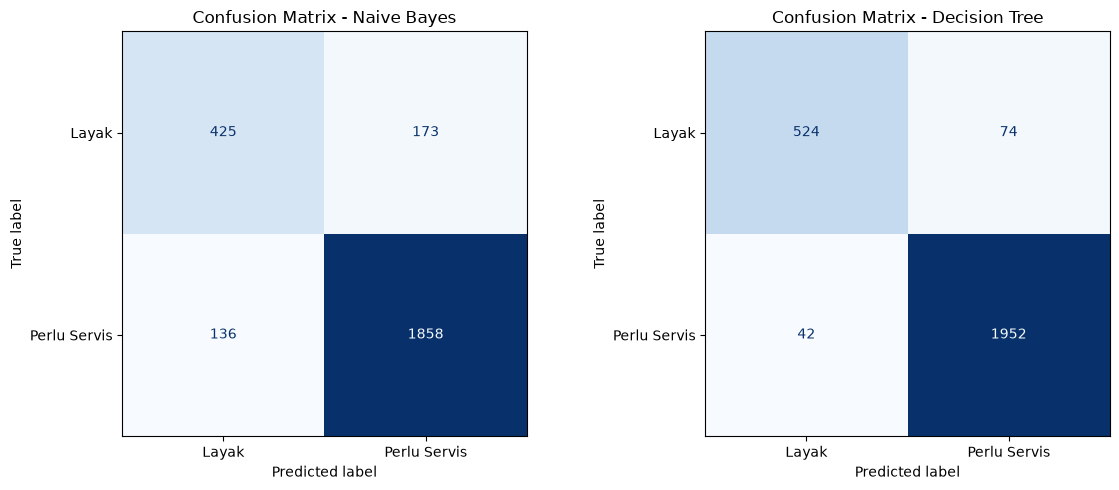

In [9]:
fig, axes = plt.subplots(1, len(prediksi_model), figsize=(6 * len(prediksi_model), 5))

if len(prediksi_model) == 1:
    axes = [axes]

for ax, (nama_model, y_pred) in zip(axes, prediksi_model.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix - {nama_model}")

plt.tight_layout()
plt.show()

## 10. Perbandingan Performa Model

Model dengan nilai F1-score macro tertinggi dianggap memiliki performa paling baik karena mempertimbangkan precision dan recall pada kedua kelas secara seimbang.

In [10]:
display(hasil_evaluasi_df)

model_terbaik = hasil_evaluasi_df.iloc[0]
print("Model terbaik berdasarkan F1-score macro:")
print(f"{model_terbaik['model']} dengan F1-score macro = {model_terbaik['f1_score_macro']:.4f}")

,model,akurasi,precision_macro,recall_macro,f1_score_macro
1,Decision Tree,0.955247,0.944635,0.927595,0.935744
0,Naive Bayes,0.880787,0.836198,0.821249,0.828310


Model terbaik berdasarkan F1-score macro:
Decision Tree dengan F1-score macro = 0.9357


## 11. Contoh Output Prediksi dan Rekomendasi Servis

Model memprediksi kelas `Layak` atau `Perlu Servis`. Setelah itu, kolom diagnosis rule-based digunakan untuk menampilkan komponen yang perlu diperhatikan, misalnya `oli`, `rem`, `busi`, `ban`, atau `aki`.

In [11]:
model_terbaik_pipeline = models[model_terbaik["model"]]
prediksi_terbaik = model_terbaik_pipeline.predict(X_test)

hasil_prediksi = data.loc[X_test.index, [
    "id",
    "kelas",
    "jenis_servis_oli",
    "jenis_servis_rem",
    "jenis_servis_busi",
    "jenis_servis_ban",
    "jenis_servis_tertinggi",
    "komponen_perlu_servis",
]].copy()

hasil_prediksi["prediksi_kelas"] = label_encoder.inverse_transform(prediksi_terbaik)
display(hasil_prediksi.head(10))

,id,kelas,jenis_servis_oli,jenis_servis_rem,jenis_servis_busi,jenis_servis_ban,jenis_servis_tertinggi,komponen_perlu_servis,prediksi_kelas
0,853,Perlu Servis,Servis 10.000 KM,Servis 20.000 KM,Servis 10.000 KM,Servis 40.000 KM,Servis 40.000 KM,"oli, busi",Perlu Servis
1,1008,Layak,Servis 10.000 KM,Servis 40.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,"oli, rem",Layak
4,831,Layak,Servis 10.000 KM,Servis 20.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,oli,Layak
11,972,Perlu Servis,Servis 10.000 KM,Servis 20.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 20.000 KM,"oli, busi",Layak
14,975,Layak,Servis 20.000 KM,Servis 20.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 20.000 KM,busi,Layak
22,1000,Perlu Servis,Servis 10.000 KM,Servis 20.000 KM,Servis 10.000 KM,Servis 40.000 KM,Servis 40.000 KM,"oli, busi",Perlu Servis
24,933,Layak,Servis 20.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,"rem, ban",Layak
29,838,Perlu Servis,Servis 10.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 20.000 KM,Servis 20.000 KM,"oli, rem",Perlu Servis
31,865,Perlu Servis,Servis 10.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,"oli, rem",Perlu Servis
50,982,Layak,Servis 20.000 KM,Servis 10.000 KM,Servis 20.000 KM,Servis 40.000 KM,Servis 40.000 KM,rem,Layak


In [12]:
MODEL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

models_produksi = {}
for nama_model, model in models.items():
    model.fit(X, y)
    models_produksi[nama_model] = model

model_bundle = {
    "models": models_produksi,
    "model": models_produksi[model_terbaik["model"]],
    "label_encoder": label_encoder,
    "feature_columns": X.columns.tolist(),
    "model_name": model_terbaik["model"],
    "metrics": hasil_evaluasi_df.to_dict(orient="records"),
}

joblib.dump(model_bundle, MODEL_OUTPUT_PATH)
print(f"Model berhasil disimpan ke: {MODEL_OUTPUT_PATH}")

Model berhasil disimpan ke: api\model_kendaraan.pkl


## 12. Visualisasi Decision Tree

Visualisasi dibatasi kedalaman 3 level agar struktur pohon tetap mudah dibaca.

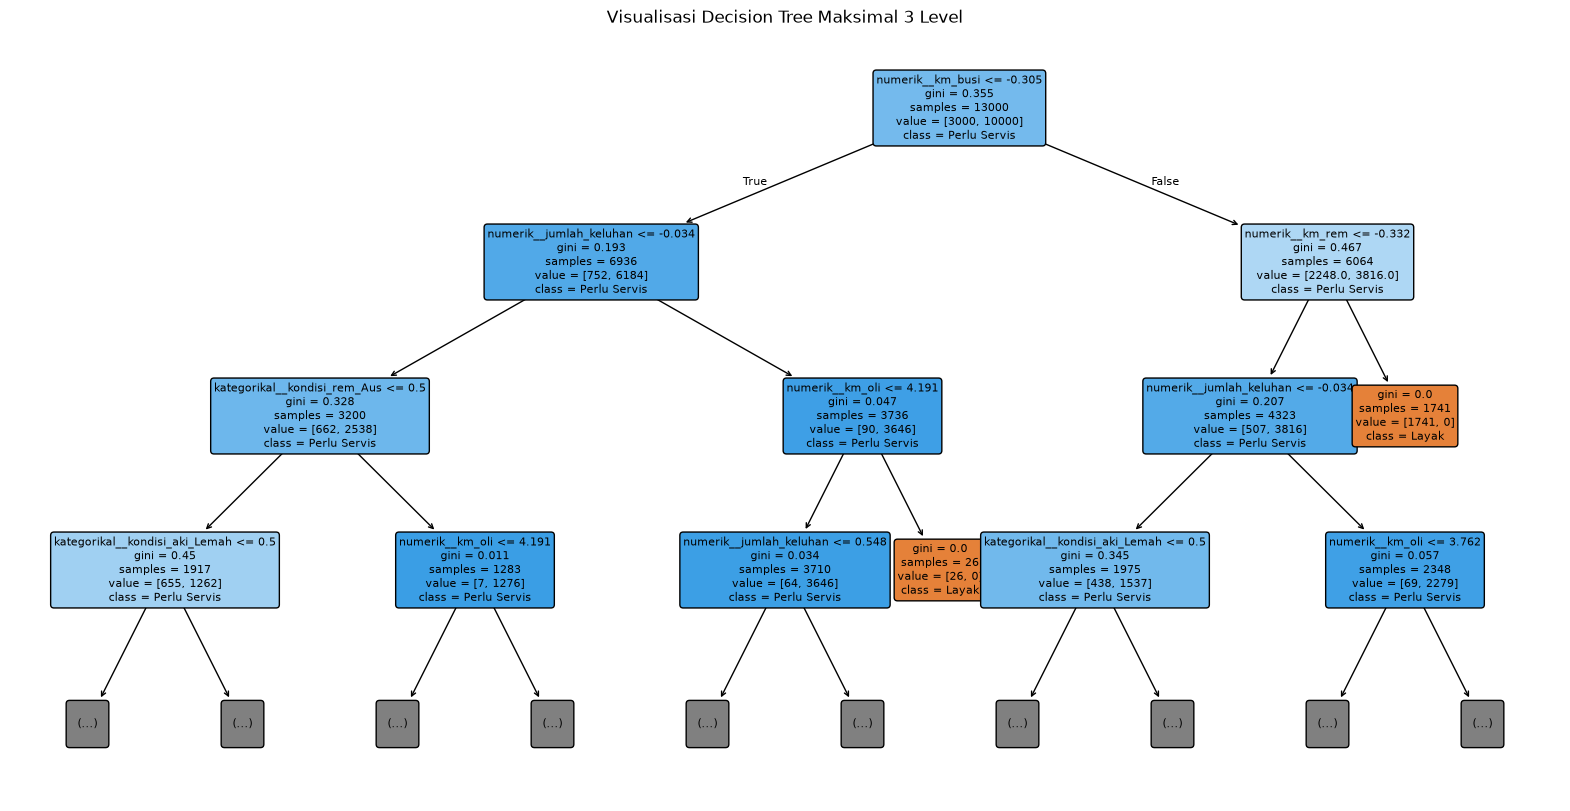

In [13]:
preprocess_dt = model_decision_tree.named_steps["preprocess"]
fitur_setelah_preprocessing = preprocess_dt.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    model_decision_tree.named_steps["model"],
    feature_names=fitur_setelah_preprocessing,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Visualisasi Decision Tree Maksimal 3 Level")
plt.show()